# Spiking Poisson Diffusion for Audio Denoising using Spiking Neural Networks

## Overview

This notebook presents a diffusion-inspired audio denoising framework implemented using Spiking Neural Networks (SNNs). The objective is to investigate whether spike-based neural systems can learn to reverse stochastic corruption in audio waveforms using biologically inspired temporal dynamics.

The implementation combines:

- Diffusion-style noise corruption
- Poisson spike-based stochasticity
- Spiking neural computation
- Temporal denoising learning

The system is trained to predict injected corruption at arbitrary diffusion timesteps and reconstruct cleaner audio representations from noisy waveforms.

# Motivation

Diffusion models have recently demonstrated strong performance in generative modeling and denoising tasks by learning to reverse a gradual corruption process.

At the same time, Spiking Neural Networks provide:

- Event-driven computation
- Temporal neural processing
- Biological plausibility
- Potential energy efficiency

This work explores whether diffusion-style denoising objectives can be integrated with spike-based neural architectures for audio processing applications.

# Objectives

The primary objectives of this implementation are:

- Implement a forward corruption process using Poisson-based stochastic noise
- Train a spiking neural network to predict injected corruption
- Learn reverse denoising from noisy audio waveforms
- Evaluate denoising quality using waveform reconstruction metrics
- Analyze whether spike-based systems can approximate diffusion denoising behavior

# Environment and Hyperparameter Setup

This section initializes all important hyperparameters used throughout the notebook.

The configuration includes:

- Audio waveform length
- Diffusion timesteps
- SNN simulation steps
- Training epochs
- Batch size
- Sampling rate
- Spike generation parameters
- Device configuration

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from torch.utils.data import (DataLoader, Subset, random_split)
import snntorch as snn
from snntorch import spikegen, surrogate

In [2]:
L = 4000

diffusion_steps = 100
num_steps = 20
epochs = 25
batch_size = 64
sr = 16000
MAX_RATE = 0.85
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


## Forward Corruption Process

A diffusion-inspired stochastic corruption process is implemented using:

- Poisson spike noise
- Timestep-dependent decay
- Additional Gaussian perturbation

The corruption intensity progressively increases across diffusion timesteps.

In [3]:
#FORWARD CORRUPTION

def get_poisson_spike_noised_sample(x0, t):

    t = t.view(-1, 1).to(DEVICE)

    gamma = torch.exp(-0.04 * t.float() * 7 / diffusion_steps)

    clean_rate = torch.clamp(x0 * gamma * MAX_RATE, min=1e-4)

    poisson_counts = torch.poisson(clean_rate * 12.0)

    noisy_rate = poisson_counts / 12.0

    gaussian_noise = (torch.randn_like(noisy_rate)*0.07*(1 - gamma))

    noisy = torch.clamp(noisy_rate + gaussian_noise, 0.0, 1.0)

    actual_noise = noisy - x0

    return noisy, actual_noise

## Dataset Preparation

The SpeechCommands dataset is used for evaluating spike-based audio denoising.

Each waveform undergoes:

- Resampling
- Mono conversion
- Padding or cropping
- Min-max normalization

This ensures consistent waveform dimensions for neural processing.

In [4]:
class PoissonSpikeAudioDataset(torch.utils.data.Dataset):

    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):

        waveform, sample_rate, *_ = self.subset[idx]

        # Resample if needed
        if sample_rate != sr:

            waveform = torchaudio.functional.resample(waveform, sample_rate, sr)

        # Convert to mono
        waveform = waveform.mean(dim=0)

        # Pad or crop
        if waveform.shape[0] < L:

            waveform = F.pad(waveform, (0, L - waveform.shape[0]))

        else:

            waveform = waveform[:L]

        # Min-max normalize
        waveform = (waveform - waveform.min())/(waveform.max() - waveform.min() + 1e-8)

        return waveform

# Spiking Neural Network Architecture

## Model Overview

The denoising model is implemented using a Spiking Neural Network (SNN) composed of:

- Timestep conditioning module
- Rate-based spike encoding
- Fully connected layers
- Leaky Integrate-and-Fire (LIF) neurons
- Temporal spike simulation

The network receives:

- A noisy waveform
- The current diffusion timestep

Its objective is to predict the corruption injected into the waveform.

---

## Timestep Conditioning

Diffusion models require timestep awareness because the corruption level changes across timesteps.

To provide timestep information to the network:

- The timestep is passed through a small multilayer perceptron (MLP)
- The resulting embedding is added to the noisy waveform
- This conditions the model on the current diffusion state

---

## Spike-Based Processing

The conditioned waveform is converted into spike trains using rate encoding.

The network then performs temporal computation over multiple simulation steps using:

- Fully connected transformations
- Leaky Integrate-and-Fire neurons
- Membrane state dynamics

The outputs across all timesteps are accumulated and averaged to produce the final predicted noise estimate.

In [5]:
#MODEL

class SpikingPoissonNoisePredictor(nn.Module):

    def __init__(self, input_dim=L, hidden=1024, beta=0.85):

        super().__init__()

        # Timestep embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

        # First FC + LIF block
        self.fc1 = nn.Linear(input_dim, hidden)

        self.lif1 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

        # Second FC + LIF block
        self.fc2 = nn.Linear(hidden, hidden)

        self.lif2 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

        # Output layer
        self.fc_out = nn.Linear(hidden, input_dim)

    def forward(self, x_noisy, t):

        # Time embedding
        t_emb = self.time_mlp(t.unsqueeze(-1).float() / diffusion_steps)

        # Condition noisy waveform
        x = x_noisy + t_emb

        # Rate encoding
        spk_in = spikegen.rate(x, num_steps=num_steps)

        # Initialize membrane states
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        output_sum = 0

        # Temporal spike simulation
        for step in range(num_steps):

            cur1 = self.fc1(spk_in[step])

            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)

            spk2, mem2 = self.lif2(cur2, mem2)

            output_sum += self.fc_out(mem2)

        return torch.tanh(output_sum / num_steps)

## Dataset Setup

The SpeechCommands dataset is divided into training and testing subsets.

PyTorch DataLoaders are used for efficient mini-batch loading during training and evaluation.

In [6]:
#DATASET SETUP

os.makedirs("./data", exist_ok=True)

base_dataset = torchaudio.datasets.SPEECHCOMMANDS(root="./data", download=True)

# Small subset
full_subset = Subset(base_dataset, range(800))

# Train/Test split
train_size = int(0.8 * len(full_subset))
test_size = len(full_subset) - train_size

train_subset, test_subset = random_split(full_subset, [train_size, test_size])

# Dataset objects
train_dataset = PoissonSpikeAudioDataset(train_subset)
test_dataset = PoissonSpikeAudioDataset(test_subset)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

## Model Initialization

The spiking denoising network, optimizer, and reconstruction loss function are initialized before training.

In [7]:
model = SpikingPoissonNoisePredictor().to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=7e-4, weight_decay=1e-5)

loss_fn = nn.MSELoss()

## Training Procedure

The model is trained to predict injected corruption at randomly sampled diffusion timesteps.

For each batch:

- A random timestep is selected
- The waveform is corrupted using the forward diffusion process
- The SNN predicts the injected noise
- Mean Squared Error (MSE) is minimized

In [8]:
#TRAINING

print("Training Started...\n")

loss_history=[]

for epoch in range(epochs):

    model.train()
    total_loss=0

    for x0 in train_loader:

        x0=x0.to(DEVICE)

        # Random timestep
        t=torch.randint(0, diffusion_steps, (x0.shape[0],), device=DEVICE)

        # Corrupt waveform
        noisy,actual_noise=get_poisson_spike_noised_sample(x0,t)

        # Predict noise
        pred_noise=model(noisy,t)

        # Compute loss
        loss=loss_fn(pred_noise,actual_noise)

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss+=loss.item()

    avg_train_loss=total_loss/len(train_loader)

    loss_history.append(avg_train_loss)

    print(
        f"Epoch {epoch+1:2d}/{epochs} "
        f"| Train Loss: {avg_train_loss:.5f}")

print("\nTraining Completed!")

Training Started...

Epoch  1/25 | Train Loss: 0.07381
Epoch  2/25 | Train Loss: 0.03490
Epoch  3/25 | Train Loss: 0.03349
Epoch  4/25 | Train Loss: 0.03318
Epoch  5/25 | Train Loss: 0.03294
Epoch  6/25 | Train Loss: 0.03256
Epoch  7/25 | Train Loss: 0.03245
Epoch  8/25 | Train Loss: 0.03219
Epoch  9/25 | Train Loss: 0.03222
Epoch 10/25 | Train Loss: 0.03225
Epoch 11/25 | Train Loss: 0.03223
Epoch 12/25 | Train Loss: 0.03218
Epoch 13/25 | Train Loss: 0.03210
Epoch 14/25 | Train Loss: 0.03209
Epoch 15/25 | Train Loss: 0.03197
Epoch 16/25 | Train Loss: 0.03196
Epoch 17/25 | Train Loss: 0.03195
Epoch 18/25 | Train Loss: 0.03208
Epoch 19/25 | Train Loss: 0.03207
Epoch 20/25 | Train Loss: 0.03218
Epoch 21/25 | Train Loss: 0.03246
Epoch 22/25 | Train Loss: 0.03204
Epoch 23/25 | Train Loss: 0.03200
Epoch 24/25 | Train Loss: 0.03207
Epoch 25/25 | Train Loss: 0.03200

Training Completed!


## Quantitative Evaluation

Model performance is evaluated using:

- Noise prediction loss
- Noisy waveform reconstruction error
- Denoised waveform reconstruction error

Mean Squared Error (MSE) is used for comparison.

In [9]:
#TEST EVALUATION

model.eval()

test_loss=0

mse_noisy_total=0
mse_denoised_total=0

with torch.no_grad():

    for x0 in test_loader:

        x0=x0.to(DEVICE)

        # Random timestep
        t=torch.randint(0, diffusion_steps, (x0.shape[0],),device=DEVICE)

        # Generate noisy waveform
        noisy,actual_noise=get_poisson_spike_noised_sample(x0,t)

        # Predict corruption
        pred_noise=model(noisy,t)

        # Denoise
        denoised=torch.clamp(noisy-pred_noise, 0.0, 1.0)

        # Noise prediction loss
        loss=loss_fn(pred_noise,actual_noise)

        test_loss+=loss.item()

        # Reconstruction metrics
        mse_noisy=F.mse_loss(noisy,x0)
        mse_denoised=F.mse_loss(denoised,x0)

        mse_noisy_total+=mse_noisy.item()
        mse_denoised_total+=mse_denoised.item()

avg_test_loss=test_loss/len(test_loader)
avg_noisy_mse=mse_noisy_total/len(test_loader)
avg_denoised_mse=mse_denoised_total/len(test_loader)

print("\n========================= RESULTS =========================")

print(f"Test Noise Prediction Loss : {avg_test_loss:.5f}")
print(f"Noisy Waveform MSE         : {avg_noisy_mse:.5f}")
print(f"Denoised Waveform MSE      : {avg_denoised_mse:.5f}")


========================= RESULTS =========================
Test Noise Prediction Loss : 0.03124
Noisy Waveform MSE         : 0.04929
Denoised Waveform MSE      : 0.03015


## Training Dynamics

The following curve visualizes the evolution of training loss across epochs during optimization.

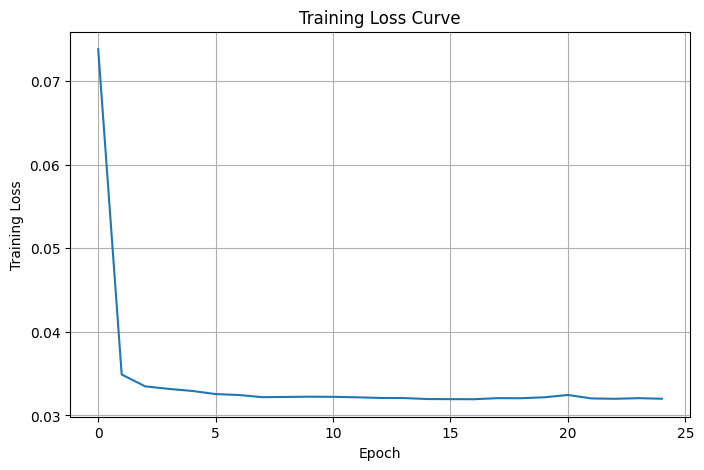

In [10]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title("Training Loss Curve")

plt.grid(True)

plt.show()

## Qualitative Analysis

The denoising capability of the trained SNN is analyzed by comparing:

- Original waveform
- Corrupted waveform
- Reconstructed waveform

This visualization helps evaluate whether the model successfully recovers waveform structure after stochastic corruption.

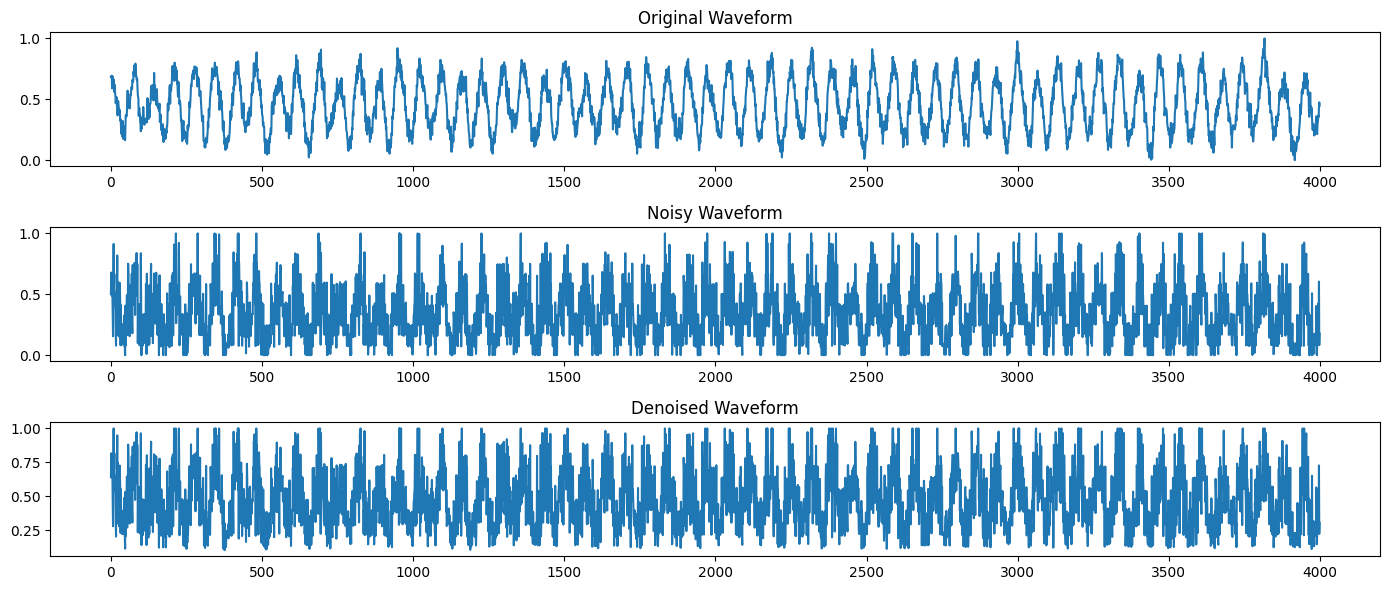

In [11]:
model.eval()

with torch.no_grad():

    x0=next(iter(test_loader)).to(DEVICE)

    t=torch.full(
        (x0.shape[0],),
        diffusion_steps//2,
        device=DEVICE
    )

    noisy,_=get_poisson_spike_noised_sample(x0,t)

    pred_noise=model(noisy,t)

    denoised=torch.clamp(
        noisy-pred_noise,
        0.0,
        1.0
    )

plt.figure(figsize=(14,6))

# Original
plt.subplot(3,1,1)
plt.plot(x0[0].cpu().numpy())
plt.title("Original Waveform")

# Noisy
plt.subplot(3,1,2)
plt.plot(noisy[0].cpu().numpy())
plt.title("Noisy Waveform")

# Denoised
plt.subplot(3,1,3)
plt.plot(denoised[0].cpu().numpy())
plt.title("Denoised Waveform")

plt.tight_layout()
plt.show()

## Conclusion

This study demonstrates that diffusion-style denoising objectives can be integrated with Spiking Neural Networks for audio waveform reconstruction.

### Key Findings

- The SNN successfully learns to predict injected stochastic corruption
- Denoised waveforms achieve lower reconstruction error than noisy inputs
- Spike-based temporal processing can approximate reverse diffusion behavior

### Limitations

- Temporal spike simulation is computationally expensive
- Reconstruction quality remains limited
- Performance depends heavily on corruption scheduling and training duration

### Future Directions

- Deeper spiking architectures
- Improved diffusion schedules
- Full spike-based generative sampling
- Neuromorphic hardware deployment

### Takeaway

The experiment provides a proof-of-concept for combining diffusion-inspired denoising with spike-based neural computation in audio processing systems.